# Latihan: Data Cleaning dan Transformation
Pada latihan sebelumnya, Anda telah berhasil memuat data (data loading) train.csv dan test.csv. Namun, data tersebut masih perlu Anda lakukan pemeriksaan untuk mengetahui kualitas data yang digunakan. 

<div style="border-left: 1px solid white;">
    <div style="margin-left: 2%;">
            <b>Catatan</b>
        <p>Proses data cleaning ini tidak perlu dilakukan semuanya karena tidak semua data memiliki karakteristik yang sama. Pada latihan ini, Anda akan melakukan cleaning terhadap train.csv, silakan lakukan secara mandiri untuk data test.csv, ya.
        </p>
    </div>
</div>

In [2]:
import pandas as pd

# Show all columns
pd.set_option('display.max_columns', None)

# Or set to a specific number higher than 84
pd.set_option('display.max_columns', 100)

# Also helpful settings:
pd.set_option('display.max_rows', 200)  # Show more rows
pd.set_option('display.width', None)    # Auto-detect width
pd.set_option('display.max_colwidth', None)  # Show full column content

#### Test Head & Train Head Dataset
<b>Note:</b> Tidak masuk dalam materi, hanya untuk makesure saja.

## Mengidentifikasi Informasi Dataset
<p>Kita akan melihat informasi dasar tentang dataset, seperti jumlah baris, kolom, tipe data, dan jumlah nilai yang hilang.</p>
<p>Pertama-tama, mari kita periksa tipe data dari masing-masing fitur yang ada di dataset. Tujuan dari pemeriksaan tipe data ini adalah untuk memastikan seluruh tipe data yang ada sudah sesuai dan tidak ada kekeliruan (contoh: data numerik terdeteksi str (string)). Sehingga, pada akhirnya Anda tidak akan mengalami kesulitan ketika melakukan preprocessing data karena tipe data yang ada sudah sesuai dan bisa melalui proses dengan lebih seamless.</p>

In [18]:
# Menampilkan ringkasan informasi dari dataset
"""Wajib di load dulu dataset sebelum menjalankan metode info()"""
train = pd.read_csv(r"dataset/train.csv")  # or test.csv
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<p>Selanjutnya, Anda perlu melakukan analisis statistik deskriptif dari dataset yang digunakan. Tujuan analisis statistik deskriptif dalam proses data cleaning pada machine learning adalah untuk memahami karakteristik dasar dari data yang sedang diproses. Beberapa tujuan utama dari proses ini adalah sebagai berikut.</p>
<ul>
    <li style="margin-bottom: 1%;">
        <b>Memahami Distribusi Data:</b> statistik deskriptif ini akan membantu Anda dalam memahami bagaimana data terdistribusi, termasuk melihat nilai rata-rata (mean), median, modus, rentang (range), dan variabilitas (standard deviation). Ini penting untuk mengidentifikasi data yang mungkin tidak seimbang (imbalance) atau memiliki distribusi yang tidak normal.
    </li>
    <li style="margin-bottom: 1%;">
        <b>Mengidentifikasi Anomali dan Outlier:</b> analisis deskriptif dapat membantu dalam mendeteksi nilai-nilai yang tidak wajar atau outlier yang bisa memengaruhi performa model. Masih ingatkan penjelasan tentang outlier pada materi sebelumnya? Jika Anda ragu, jangan sungkan untuk me-review ulang kembali materinya, ya.
    </li>
    <li style="margin-bottom: 1%;">
        <b>Menilai Kualitas Data:</b> dengan analisis deskriptif, dapat diketahui apakah ada missing values, data duplikat, atau inkonsistensi dalam dataset. Ini penting untuk memastikan bahwa data bersih dan siap digunakan untuk model machine learning.
    </li>
    <li style="margin-bottom: 1%;">
        <b>Mempermudah Pemahaman Data:</b> statistik deskriptif menyajikan informasi data dalam bentuk yang lebih sederhana, seperti tabel, grafik, dan summary statistics, yang memudahkan pemahaman atas kondisi data yang ada.
    </li>
    <li style="margin-bottom: 1%;">
        <b>Menentukan Transformasi Data yang Diperlukan:</b> dari hasil analisis deskriptif, bisa ditentukan apakah diperlukan transformasi data, seperti normalisasi atau standardisasi, agar data lebih sesuai untuk algoritma machine learning yang akan digunakan.
    </li>
</ul>
<p>Dengan melakukan analisis statistik deskriptif, kita bisa memastikan bahwa data yang digunakan untuk melatih model machine learning adalah data yang representatif, berkualitas tinggi, dan bebas dari masalah yang dapat memengaruhi hasil akhir. Berikut adalah contoh kode untuk melakukan analisis deskriptif.</p>

In [17]:
# Menampilkan statistik deskriptif dari dataset
train.describe(include="all")
print(train)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities LotConfig LandSlope Neig

Terakhir Anda perlu melakukan pemeriksaan terhadap data yang hilang (missing value). Tujuannya untuk mencegah kesalahan ketika melakukan analisis, mencegah error pada model, dan meningkatkan performa model. Dengan melakukan pemeriksaan missing value, Anda dapat memastikan bahwa proses analisis data dan pelatihan model machine learning berjalan dengan baik sehingga hasil yang diperoleh lebih valid dan akurat. Berikut salah satu contoh kode untuk melakukan pemeriksaan missing value.

In [19]:
# Memeriksa jumlah nilai yang hilang di setiap kolom
missing_values = train.isnull().sum()
missing_values[missing_values > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

## Mengatasi Missing Value
<p>Perhatikan jumlah data yang hilang pada hasil kode sebelumnya, tentunya sangat banyak sekali data yang hilang ‘kan? Sebagai informasi jumlah data pada train.csv ini berjumlah 1460 baris sehingga jika salah satu fitur memiliki missing value lebih dari 1000, dapat kita asumsikan terlalu banyak data yang hilang. Lalu bagaimana solusinya?</p>
<p>Pertama-tama, mari kita pisahkan kolom yang memiliki missing value lebih dari 75% dan kurang dari 75%.</p>

In [20]:
"""Mengatasi Missing Value"""
# lanjutan dari var missing_values diatas tersebut
less = missing_values[missing_values < 1000].index
over = missing_values[missing_values >= 1000].index
print(less)
print(over)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodD

<p>Berdasarkan hasil dari langkah sebelumnya, kita akan memutuskan bagaimana menangani nilai yang hilang dengan dua cara:</p>

#### Cara 1: Mengisi Nilai yang Hilang
<p>data di atas terdapat beberapa fitur yang memiliki missing value kurang dari 75% dari jumlah skala pada data. Namun, perlu Anda catat bahwa seluruh fitur tersebut memiliki tipe data yang berbeda. Sehingga penanganan missing value-nya pun perlu dibedakan</p>
<p>Mari kita mulai dengan mengatasi missing value untuk tipe data numerik:</p>

In [21]:
# Contoh mengisi nilai yang hilang dengan median untuk kolom numerik
numeric_features = train[less].select_dtypes(include=['number']).columns
train[numeric_features] = train[numeric_features].fillna(train[numeric_features].median())
print(train[numeric_features])

        Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
0        1          60         65.0     8450            7            5   
1        2          20         80.0     9600            6            8   
2        3          60         68.0    11250            7            5   
3        4          70         60.0     9550            7            5   
4        5          60         84.0    14260            8            5   
...    ...         ...          ...      ...          ...          ...   
1455  1456          60         62.0     7917            6            5   
1456  1457          20         85.0    13175            6            6   
1457  1458          70         66.0     9042            7            9   
1458  1459          20         68.0     9717            5            6   
1459  1460          20         75.0     9937            5            6   

      YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  \
0          2003          2003  

Perbandingan antara Sebelum & Sesudah diberi pengisian Missing Values

In [22]:
import pandas as pd

# df = pd.read_csv(r"dataset/train.csv")

# Before filling
print("Before:")
print(df.isnull().sum())

# Fill ALL numeric columns with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# After filling
print("\nAfter:")
print(df.isnull().sum())

Before:
Id                  0
MSSubClass          0
MSZoning            0
LotFrontage         0
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          0
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
Lo

Coba kita lihat data type pada hasil column after yang masih ada missing values:

In [23]:
df[df.columns[df.isnull().any()]].dtypes

Alley           object
MasVnrType      object
BsmtQual        object
BsmtCond        object
BsmtExposure    object
BsmtFinType1    object
BsmtFinType2    object
Electrical      object
FireplaceQu     object
GarageType      object
GarageFinish    object
GarageQual      object
GarageCond      object
PoolQC          object
Fence           object
MiscFeature     object
dtype: object

<p>Dari hasil diatas, proven bahwa data type missing values yang terisi bersifat Int dan Float.</p>
<p>Oke! Lanjut ke materi dicoding...</p>

Secara singkat <b>kode di atas memiliki dua fungsi utama</b> yaitu sebagai berikut:
<ul>
    <li>Baris pertama memilih nama-nama kolom dari DataFrame train yang memiliki tipe data numerik dari subset kolom yang ditentukan oleh less.</li>
    <li>Baris kedua kemudian mengisi semua nilai yang hilang (NaN) pada kolom-kolom numerik tersebut dengan nilai median dari masing-masing kolom.</li>
</ul>
<p>Secara keseluruhan, kode ini bertujuan untuk membersihkan data dengan memastikan bahwa semua kolom numerik dalam subset tertentu (train[less]) tidak memiliki missing value (NaN) dengan menggantinya menggunakan nilai median kolom masing-masing.</p>
<p>Selanjutnya, kita perlu menangani permasalahan yang serupa pada data yang bertipe object atau string. Sedikit berbeda dengan kasus data numerik, pada kasus ini kita tidak bisa menggunakan median, mean, atau fungsi agregasi lainnya. Biasanya ada dua cara yang sering dilakukan untuk mengatasi permasalahan missing value pada data kategori.</p>
<ul>
    <li><b>Mengisi Missing Value dengan Modus (Nilai yang Paling Sering Muncul):</b> pendekatan ini cukup umum karena nilai modus sering kali merupakan representasi yang baik untuk data yang hilang dalam konteks kategorikal.</li>
    <li><b>Mengisi dengan Kategori Baru (Misalnya "Unknown" atau "Missing"):</b> ini adalah cara lain untuk menangani missing value dengan menandai data yang hilang sebagai kategori baru.</li>
</ul>
<p>Pada contoh kasus ini, mari kita atasi dengan mengisi missing value dengan modus atau nilai yang paling sering muncul pada masing-masing fitur.</p>

In [34]:
# Contoh mengisi nilai yang hilang dengan mode untuk kolom kategori
categorical_features = train.select_dtypes(include=['object']).columns

for column in categorical_features:
    train[column] = train[column].fillna(train[column].mode()[0])
    print(f"Filled categorical column: {column}")

Filled categorical column: MSZoning
Filled categorical column: Street
Filled categorical column: Alley
Filled categorical column: LotShape
Filled categorical column: LandContour
Filled categorical column: Utilities
Filled categorical column: LotConfig
Filled categorical column: LandSlope
Filled categorical column: Neighborhood
Filled categorical column: Condition1
Filled categorical column: Condition2
Filled categorical column: BldgType
Filled categorical column: HouseStyle
Filled categorical column: RoofStyle
Filled categorical column: RoofMatl
Filled categorical column: Exterior1st
Filled categorical column: Exterior2nd
Filled categorical column: MasVnrType
Filled categorical column: ExterQual
Filled categorical column: ExterCond
Filled categorical column: Foundation
Filled categorical column: BsmtQual
Filled categorical column: BsmtCond
Filled categorical column: BsmtExposure
Filled categorical column: BsmtFinType1
Filled categorical column: BsmtFinType2
Filled categorical column: H

Re-check again for Missing Values

In [35]:
# Then Block 2 - Fill numeric columns
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    train[col] = train[col].fillna(train[col].median())

# Check result
print("\nRemaining missing values:")
print(train.isnull().sum().sum())


Remaining missing values:
0


In [37]:
# Just check remaining missing values
print(train.isnull().sum())
print("\nTotal missing:", train.isnull().sum().sum())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr

Kode di atas akan melakukan pengulangan pada setiap kolom yang berisi data kategori dalam DataFrame train. Selanjutnya, setiap kolom kategori akan melakukan proses pergantian untuk semua nilai yang hilang (NaN) dengan nilai modus dari kolom tersebut. Hasil akhirnya adalah semua kolom kategori dalam DataFrame train tidak lagi memiliki nilai yang hilang (NaN) karena semua NaN telah diisi dengan nilai modus dari kolom masing-masing.

#### Cara 2: Menghapus Kolom dengan Banyak Nilai yang Hilang:
<p>jika ada kolom dengan terlalu banyak nilai yang hilang, kita bisa mempertimbangkan untuk menghapusnya (pada kasus ini kita mengambil batasan 75%). Untuk mengatasi kasus ini sangatlah mudah, pertama Anda perlu mengambil index atau nama kolom dari fitur yang memiliki missing value lebih dari batasan yang sudah ditentukan (Anda dapat lihat kode ketika memisahkan kolom di atas). Kemudian hal yang perlu dilakukan adalah menghapus kolom tersebut sesuai dengan nama fitur yang sudah ditentukan sebelumnya</p>

In [26]:
# Menghapus kolom dengan terlalu banyak nilai yang hilang
df = train.drop(columns=over)
print(df)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street LotShape  \
0        1          60       RL         65.0     8450   Pave      Reg   
1        2          20       RL         80.0     9600   Pave      Reg   
2        3          60       RL         68.0    11250   Pave      IR1   
3        4          70       RL         60.0     9550   Pave      IR1   
4        5          60       RL         84.0    14260   Pave      IR1   
...    ...         ...      ...          ...      ...    ...      ...   
1455  1456          60       RL         62.0     7917   Pave      Reg   
1456  1457          20       RL         85.0    13175   Pave      Reg   
1457  1458          70       RL         66.0     9042   Pave      Reg   
1458  1459          20       RL         68.0     9717   Pave      Reg   
1459  1460          20       RL         75.0     9937   Pave      Reg   

     LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0            Lvl    AllPub    Inside       Gtl   

<p>Jika Anda perhatikan kode di atas, ada sebuah perubahan nama DataFrame yang kita lakukan. Hal tersebut bertujuan supaya data asli tidak berubah dan dapat kita bandingkan sebelum dan sesudah proses mengisi missing value.</p>
<p>Terakhir, lakukan pemeriksaan terhadap data yang sudah melewati tahapan verifikasi missing value dengan kode berikut.</p>

In [30]:
# lakukan pemeriksaan terhadap data yang sudah melewati tahapan verifikasi missing value
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

Seharusnya ada "0", tetapi jika tidak ada, maka Selamat! Data Anda sudah bersih dari missing values. Selamat!

## Mengatasi Outlier

<p>Seperti yang Anda ketahui bahwa outliers merupakan salah satu blocker dalam membangun model machine learning yang optimal. Hal ini bisa disebabkan oleh berbagai hal seperti kesalahan pengisian data, error yang terjadi ketika pengumpulan data, dan lain sebagainya.</p>
<p>Salah satu cara mengatasi outliers adalah dengan menggunakan metode IQR (Interquartile Range) adalah salah satu pendekatan yang efektif. IQR adalah rentang antara kuartil pertama (Q1) dan kuartil ketiga (Q3) dalam data. Nilai yang terletak di luar batas IQR dianggap sebagai outlier.</p>
<p>Mari kita periksa terlebih dahulu apakah dataset yang digunakan memiliki outlier atau tidak menggunakan kode berikut.</p>

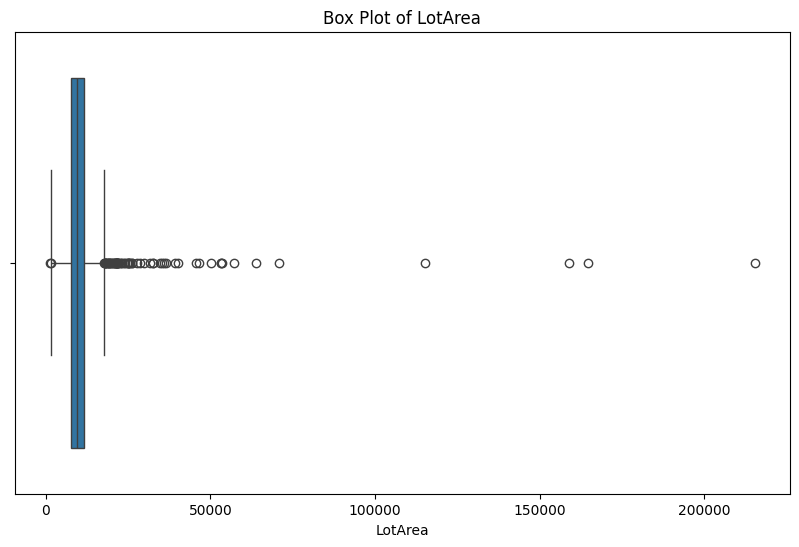

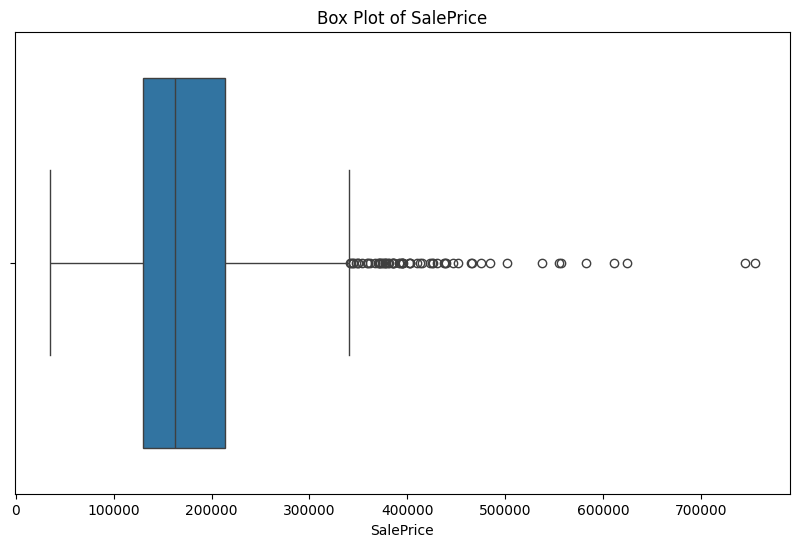

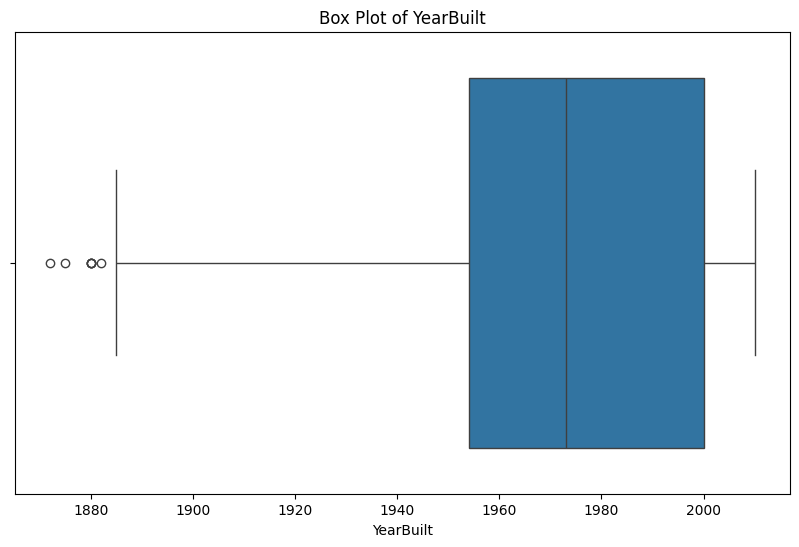

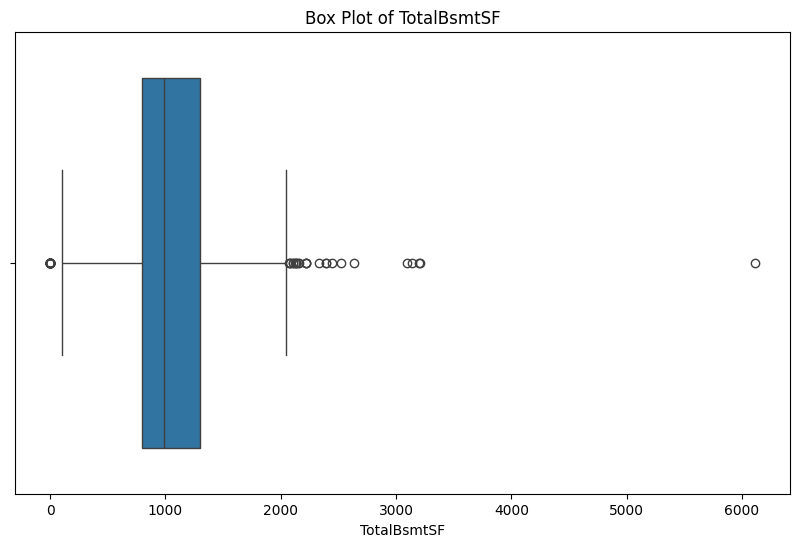

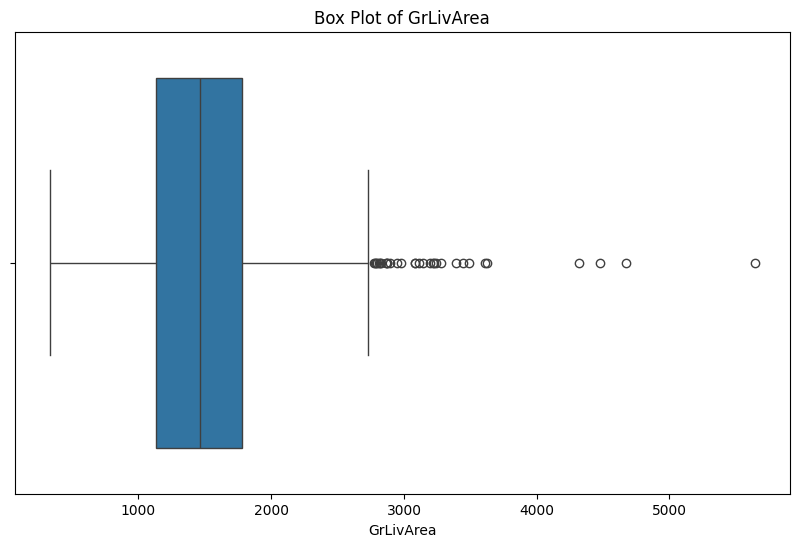

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data (adjust path as needed)
df = pd.read_csv(r"dataset/train.csv") # or test.csv

# Get all numeric columns automatically
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Manually define which columns to plot
numeric_features = ['LotArea', 'SalePrice', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea']

for feature in numeric_features:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

<div style="border-left:2px solid white;">
    <div style="margin-left: 2%">
        <p><b>Catatan</b></p>
        <p>Karena output dari kode di atas sangat banyak, kami hanya memperlihatkan salah satunya. Silakan ikuti latihan yang disediakan untuk melihat seluruh outputnya.</p>
    </div>
</div>
<p>Perhatikan visualisasi data di atas, apakah Anda dapat menyimpulkan sesuatu? Yup, nilai yang berada di bawah batas bawah atau di atas batas atas dianggap sebagai outlier. Ada dua pilihan yang biasa dilakukan untuk mengatasi permasalahan ini:</p>
<ol>
    <li>Anda dapat memilih untuk menghapus outlier.</li>
    <li>Menggantinya dengan nilai yang lebih moderat (seperti batas terdekat), atau menerapkan transformasi.</li>
</ol>
<p>Nah, pada kasus ini, kita akan memilih untuk menghapus data outlier dengan asumsi bahwa outlier yang terjadi merupakan human error dan tidak ada pengaruh yang besar pada analisis deskriptif. Mari kita mulai pemeriksaan outlier menggunakan metode IQR.</p>
<p>Berikut adalah langkah-langkah umum untuk mendeteksi dan menangani outlier menggunakan metode IQR:</p>
<ol>
    <li>Menghitung IQR, Q1, dan Q3
        <ol type="a">
            <li>Q1 (Quartile 1): Nilai di persentil ke-25 data.</li>
            <li>Q3 (Quartile 3): Nilai di persentil ke-75 data.</li>
            <li>IQR: Rentang antara Q3 dan Q1 (IQR = Q3 - Q1).</li>
        </ol>
    </li>
    <li>Menentukan Batas Bawah dan Batas Atas
        <ol type="a">
            <li>Batas Bawah: Q1 - 1.5 * IQR</li>
            <li>Batas Atas: Q3 + 1.5 * IQR</li>
        </ol>
    </li>
</ol>

<p>Langkah di atas merupakan algoritma secara umum sehingga untuk memproses metode tersebut, Anda perlu mengonversi langkah-langkah yang ada pada bahasa pemrograman yang digunakan (pada kasus ini Python).</p>

In [12]:
# Contoh sederhana untuk mengidentifikasi outliers menggunakan IQR
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1
print(Q1)
print()
print(Q3)
print()
print(IQR)

LotArea          7553.50
SalePrice      129975.00
YearBuilt        1954.00
TotalBsmtSF       795.75
GrLivArea        1129.50
Name: 0.25, dtype: float64

LotArea         11601.50
SalePrice      214000.00
YearBuilt        2000.00
TotalBsmtSF      1298.25
GrLivArea        1776.75
Name: 0.75, dtype: float64

LotArea         4048.00
SalePrice      84025.00
YearBuilt         46.00
TotalBsmtSF      502.50
GrLivArea        647.25
dtype: float64


<p>Selanjutnya mari kita hapus outlier berdasarkan perhitungan di atas:</p>

In [13]:
# Filter dataframe untuk hanya menyimpan baris yang tidak mengandung outliers pada kolom numerik
condition = ~((df[numeric_features] < (Q1 - 1.5 * IQR)) | (df[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)
df_filtered_numeric = df.loc[condition, numeric_features]

# Menggabungkan kembali dengan kolom kategorikal
categorical_features = df.select_dtypes(include=['object']).columns
df_cleaned = pd.concat([df_filtered_numeric, df.loc[condition, categorical_features]], axis=1)

In [14]:
# Melihat jumlah baris sebelum dan sesudah
print(f"Jumlah baris sebelum: {len(df)}")
print(f"Jumlah baris setelah: {len(df_cleaned)}")
print(f"Jumlah outlier yang dihapus: {len(df) - len(df_cleaned)}")
print(f"Persentase data yang tersisa: {(len(df_cleaned)/len(df)*100):.2f}%")

Jumlah baris sebelum: 1460
Jumlah baris setelah: 1279
Jumlah outlier yang dihapus: 181
Persentase data yang tersisa: 87.60%


Melihat kolom mana yang menghasilkan paling banyak outlier:

In [16]:
# Hitung outlier per kolom
for col in numeric_features:
    outliers = df[(df[col] < (Q1[col] - 1.5 * IQR[col])) | (df[col] > (Q3[col] + 1.5 * IQR[col]))]
    print(f"{col}: {len(outliers)} outliers")

LotArea: 69 outliers
SalePrice: 61 outliers
YearBuilt: 7 outliers
TotalBsmtSF: 61 outliers
GrLivArea: 31 outliers


##### Jika diatas Error

Cara 1: Call one specific column

In [ ]:
# See all column names
print(df.columns.tolist())

<Axes: xlabel='LotArea'>

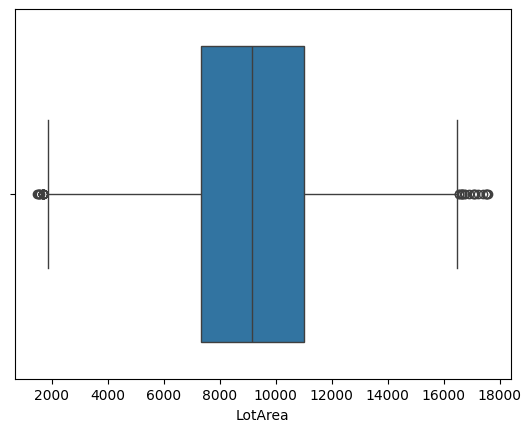

In [25]:
sns.boxplot(x=df_cleaned['LotArea'])

Cara 2: Call multiple specific columns (one by one):

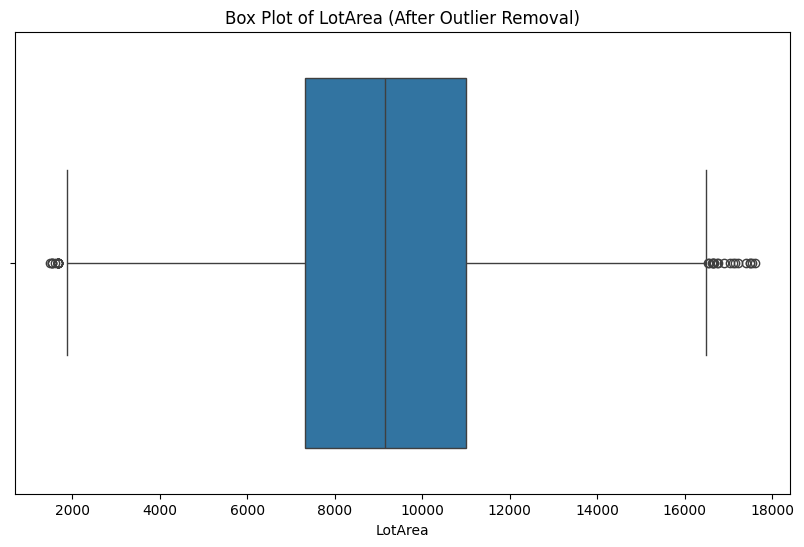

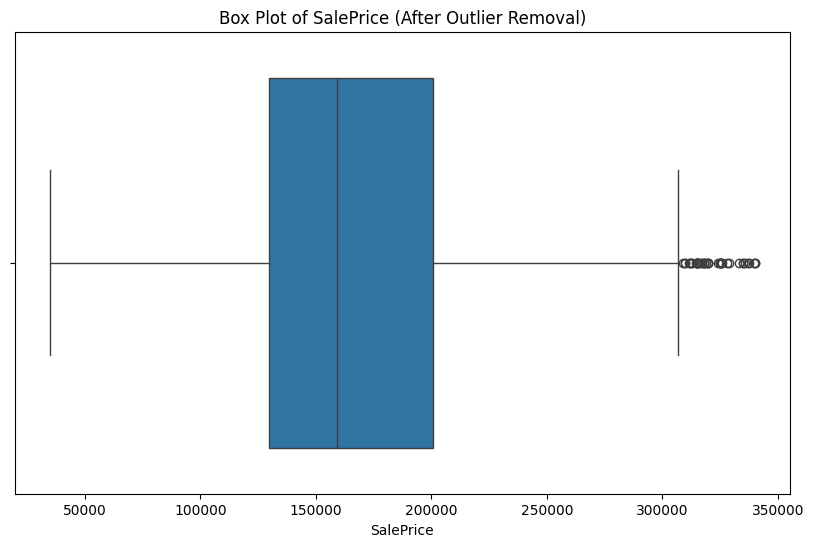

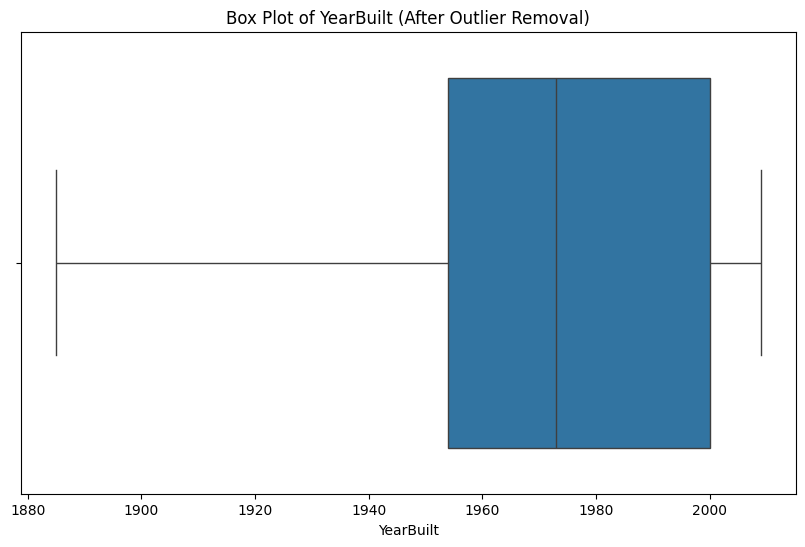

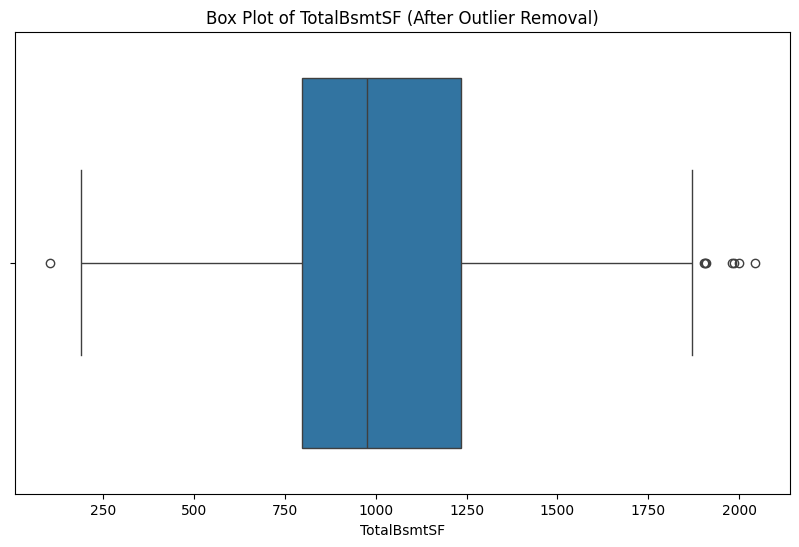

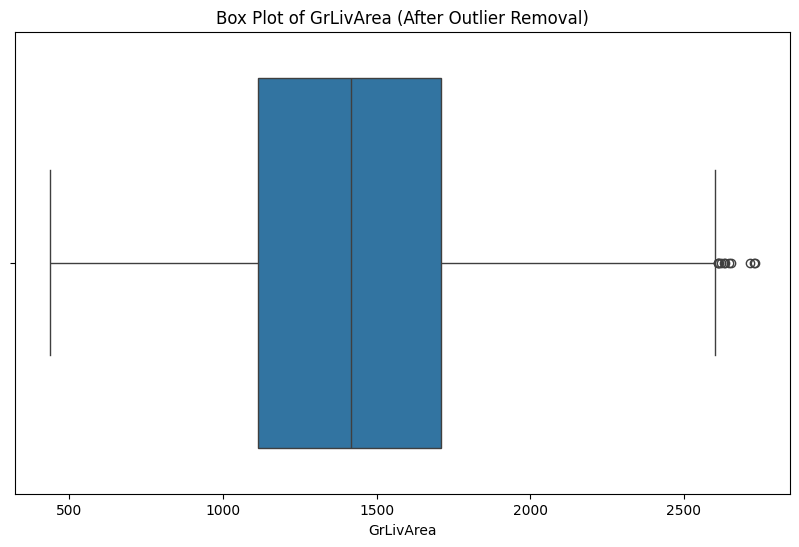

In [26]:
for col in ['LotArea', 'SalePrice', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea']:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df_cleaned[col])
    plt.title(f'Box Plot of {col} (After Outlier Removal)')
    plt.show()

Cara 3: Call ALL numeric columns automatically

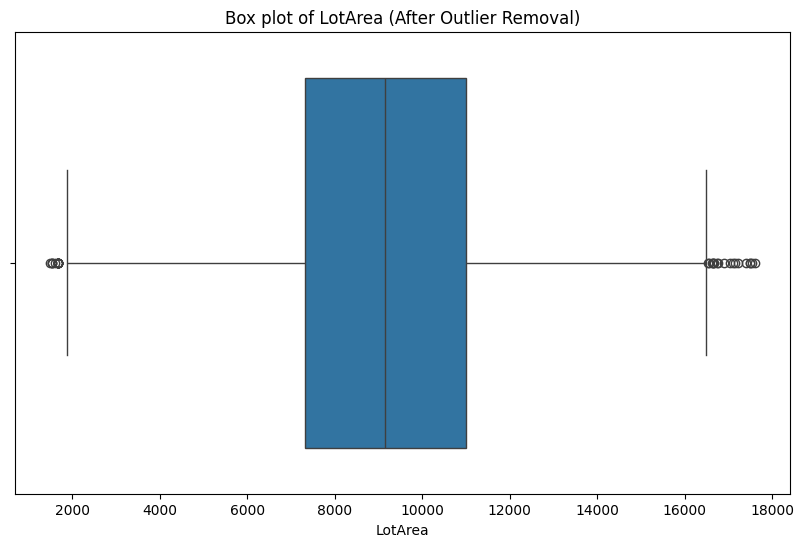

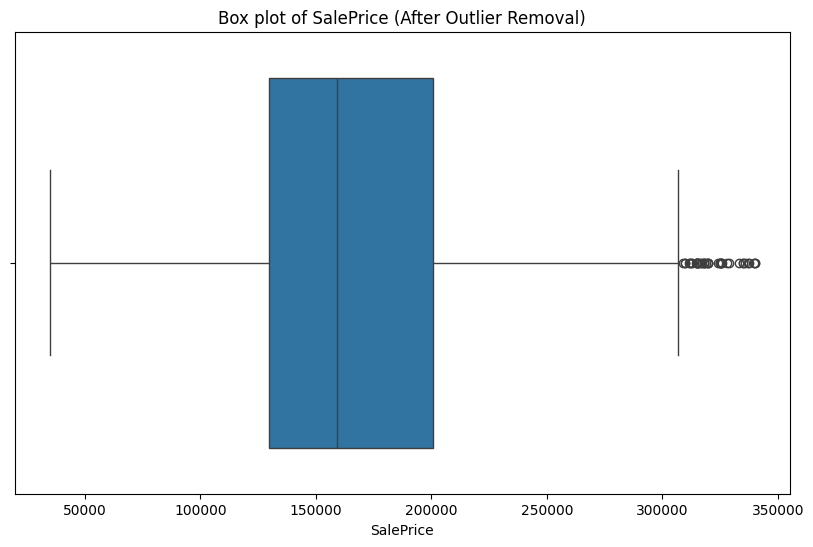

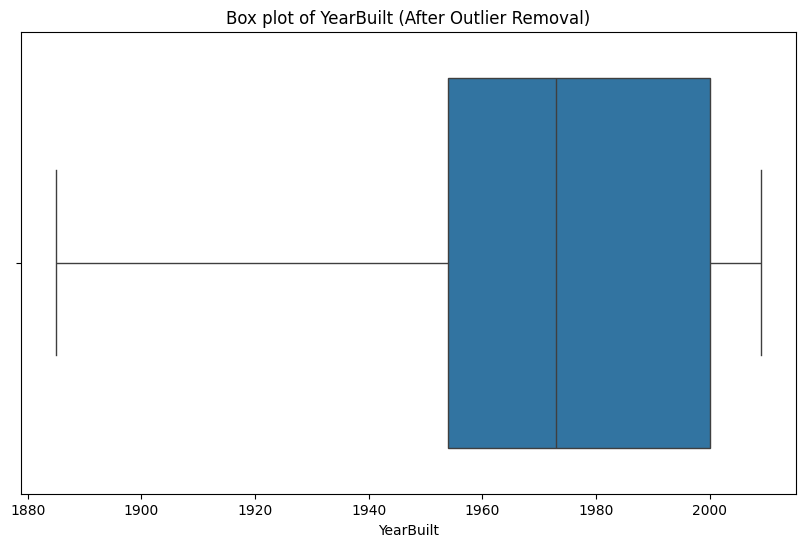

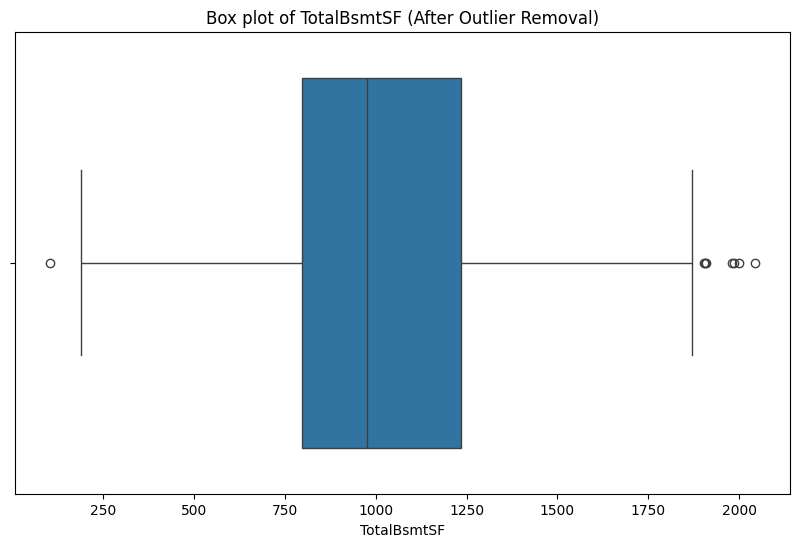

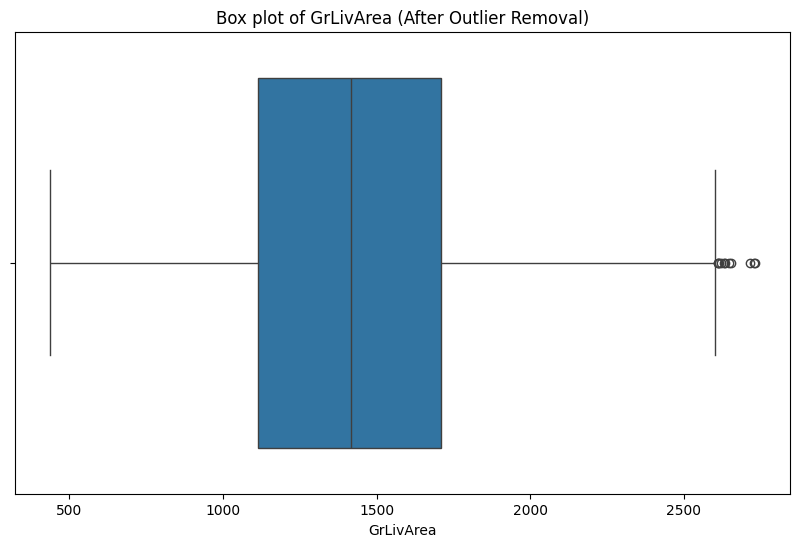

In [27]:
numeric_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numeric_features:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df_cleaned[col])
    plt.title(f'Box plot of {col} (After Outlier Removal)')
    plt.show()

Code yang lengkap untuk menghapus outlier berdasarkan IQR Sesungguhnya:

Shape sebelum: (1460, 81)
Shape sesudah: (1261, 81)


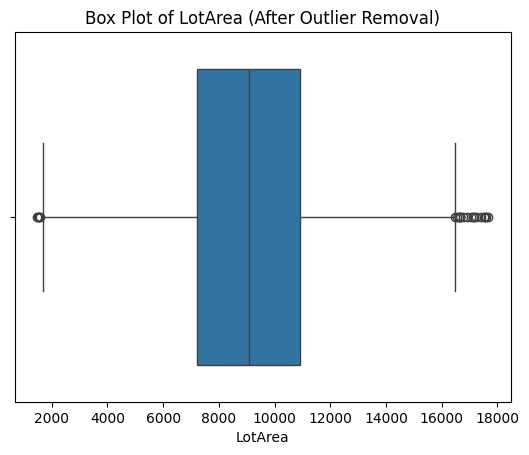

In [5]:
# Hitung Q1, Q3, dan IQR untuk kolom numerik
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_cleaned

# Terapkan ke df Anda
df_cleaned = df.copy()
for col in ['LotArea', 'SalePrice', 'TotalBsmtSF', 'GrLivArea']:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

# Bandingkan shape sebelum dan sesudah
print(f"Shape sebelum: {df.shape}")
print(f"Shape sesudah: {df_cleaned.shape}")

# Cek box plot setelah cleaning
sns.boxplot(x=df_cleaned['LotArea'])
plt.title('Box Plot of LotArea (After Outlier Removal)')
plt.show()

Show the Box Plots after Removing Outliers:

KeyError: 'OverallCond'

<Figure size 1000x600 with 0 Axes>

<p>Terakhir, mari kita bandingkan data yang telah melewati proses penanganan outliers dan sebelum melewati tahapan tersebut. Berikut adalah salah satu contoh visualisasi data yang telah melewati tahapan penanganan outliers.</p>

#### Lanjut

![alt text](image/dos-819790a948e411cbbd902b0f414dc8da20241015110130.jpg)

Apakah Anda melihat perbedaannya? Benar sekali! Setelah penanganan outliers menggunakan IQR, distribusi data menjadi lebih merata dan terpusat, dengan mean dan median yang mendekati satu sama lain. Di lain sisi, varians dan standar deviasi akan berkurang, lalu rentang data menyusut karena nilai yang berbeda telah diatasi.

<div style="border: 1px solid white">
    <div style="margin: 1%;">
        <p><b>Pro Tips:</b></p>
        <p>Jika Anda tidak ingin menghapus outliers seperti contoh di atas, silakan gunakan metode agregasi seperti berikut:</p>
        <code>
            ```<br>
            median = df['column_name'].median()<br>
            df['column_name'] = df['column_name'].apply(lambda x: median if x < (Q1 - 1.5  IQR) or x > (Q3 + 1.5  IQR) else x)<br>
            ```
        </code>
        <p>atau</p>
        <code>
            ```<br>
            # Mengganti outlier dengan nilai batas terdekat<br>
            df['column_name'] = df['column_name'].apply(lambda x: (Q1 - 1.5  IQR) if x < lower_bound else (Q3 + 1.5  IQR) if x > (Q3 + 1.5 * IQR) else x)<br>
            <br>
            <br>
            ```
        </code>
    </div>
</div>

#### Koreksi dari yang diajarkan Dicoding

<p>Kode yang benar untuk mengganti outlier (bukan menghapus):</p>
<p><b>Metode 1: Ganti dengan median</b></p>
<code>
    median = df['column_name'].median()
    Q1 = df['column_name'].quantile(0.25)
    Q3 = df['column_name'].quantile(0.75)
    IQR = Q3 - Q1

    df['column_name'] = df['column_name'].apply(lambda x: median if (x < (Q1 - 1.5 * IQR)) or (x > (Q3 + 1.5 * IQR)) else x)
</code>
<p><b>Metode 2: Ganti dengan batas terdekat (capping)</b></p>
<code>
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df['column_name'] = df['column_name'].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
</code>
<p><b>Untuk semua kolom numerik sekaligus (capping):</b></p>
<code>
    for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
</code><br>
<p>Pada bawah ini, saya menggunakan Metode 1 yakni ganti dengan median:</p>

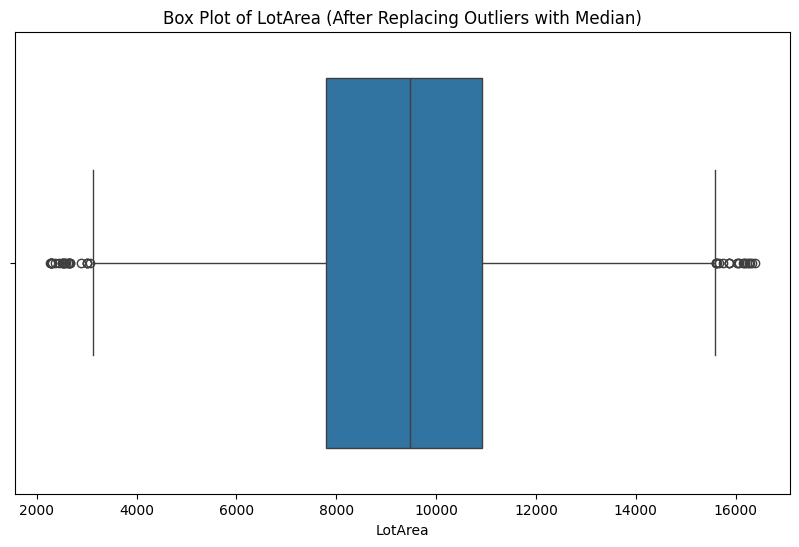

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

median = df['LotArea'].median()
Q1 = df['LotArea'].quantile(0.25)
Q3 = df['LotArea'].quantile(0.75)
IQR = Q3 - Q1

df['LotArea'] = df['LotArea'].apply(lambda x: median if (x < (Q1 - 1.5 * IQR)) or (x > (Q3 + 1.5 * IQR)) else x)

plt.figure(figsize=(10,6))
sns.boxplot(x=df['LotArea'])
plt.title('Box Plot of LotArea (After Replacing Outliers with Median)')
plt.show()


## Normalisasi dan Standardisasi Data
<p>Tahap selanjutnya dilakukan jika dataset memiliki fitur numerik dengan skala yang berbeda-beda, kita mungkin perlu melakukan normalisasi atau standardisasi. Normalisasi dan standardisasi adalah teknik preprocessing data yang digunakan untuk menyiapkan data sebelum analisis atau pemodelan. Keduanya bertujuan untuk membuat fitur memiliki skala yang seragam, tetapi mereka melakukannya dengan cara yang berbeda.</p>
<p>Sebuah pertanyaan klasik selalu muncul, “Bagaimana cara menentukan kapan harus menggunakan normalisasi atau standardisasi?”</p>

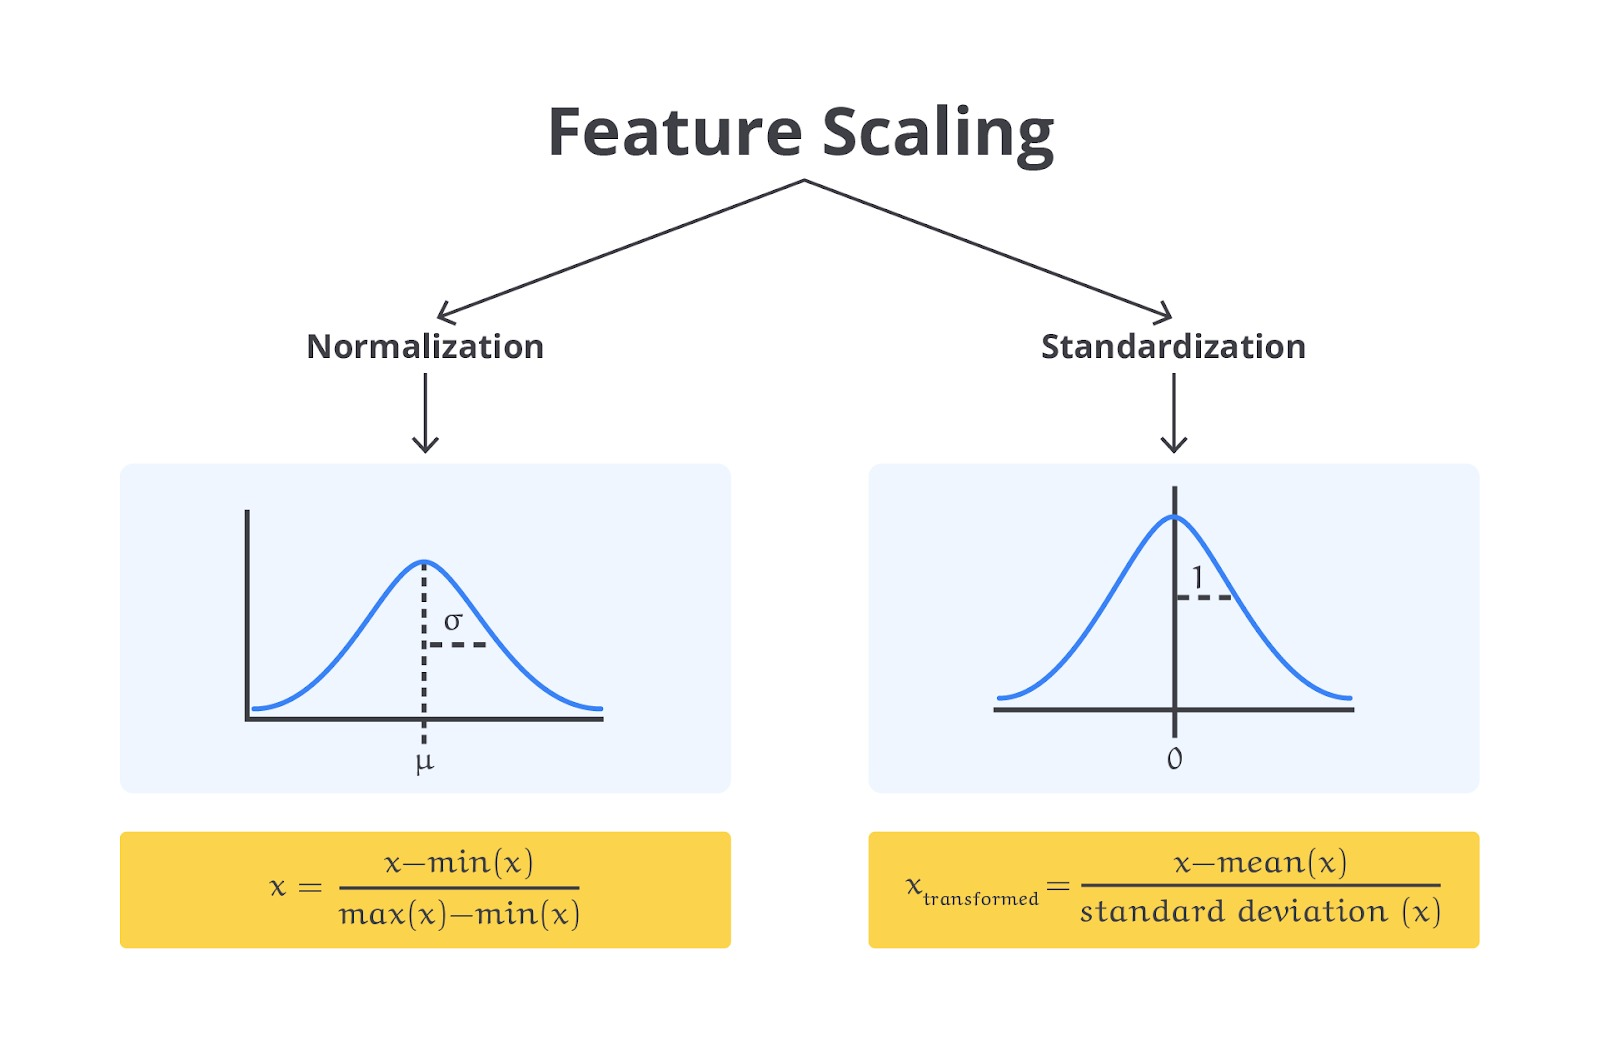

<p>Berikut adalah panduan umum untuk menentukan kapan Anda harus menggunakan normalisasi atau standardisasi:</p>
<h4><b>Normalisasi</b></h4>
<p>Normalisasi (juga dikenal sebagai penskalaan min-max) bertugas untuk mengubah fitur sehingga nilainya berada dalam rentang tertentu, biasanya antara 0 dan 1.</p>
<p>Berikut poin-poin yang menjadi pertimbangan ketika akan melakukan normalisasi:</p>
<ul>
    <li><b>Fitur dengan Skala Berbeda:</b> ketika fitur memiliki skala yang sangat berbeda dan Anda ingin menyamakan rentangnya.</li>
    <li><b>Model Berbasis Jarak:</b> jika Anda menggunakan algoritma yang bergantung pada jarak, seperti K-Nearest Neighbors (KNN) atau K-Means clustering, normalisasi dapat membantu karena model ini sensitif terhadap skala fitur.</li>
    <li><b>Data Tidak Terdistribusi Normal:</b> jika data tidak terdistribusi normal dan Anda ingin mengubah data menjadi rentang yang lebih seragam.</li>
</ul>

##### Contoh Praktek Normalisasi (Min-Max Scaling)

In [27]:
from sklearn.preprocessing import MinMaxScaler

# Contoh data
df = pd.read_csv(r"dataset/train.csv")
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# Normalisasi
scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[numeric_features] = scaler.fit_transform(df[numeric_features])

# Lihat perbedaan
print("Sebelum normalisasi (LotArea):")
print(df[['LotArea', 'SalePrice']].head())
print("\nSetelah normalisasi (skala 0-1):")
print(df_normalized[['LotArea', 'SalePrice']].head())

Sebelum normalisasi (LotArea):
   LotArea  SalePrice
0     8450     208500
1     9600     181500
2    11250     223500
3     9550     140000
4    14260     250000

Setelah normalisasi (skala 0-1):
    LotArea  SalePrice
0  0.033420   0.241078
1  0.038795   0.203583
2  0.046507   0.261908
3  0.038561   0.145952
4  0.060576   0.298709


Visualisasi Perbandingan

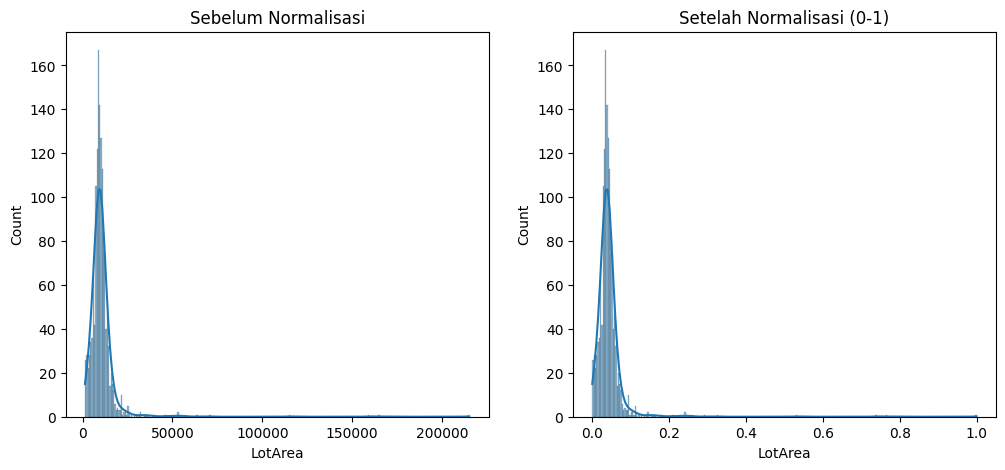

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['LotArea'], kde=True, ax=axes[0])
axes[0].set_title('Sebelum Normalisasi')

sns.histplot(df_normalized['LotArea'], kde=True, ax=axes[1])
axes[1].set_title('Setelah Normalisasi (0-1)')

plt.show()

<p>Sip, hasil diatas Setelah Normalisasi (skala 0-1) bisa kita rampingkan lagi dengan menambahkan:</p>
<code>
    figsize=(8,4)
    plt.tight_layout()
</code>
<p>agar otomatis menyesuaikan</p>

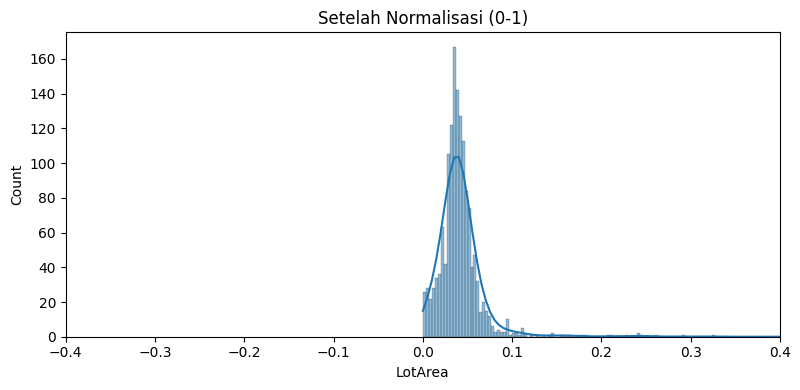

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df_normalized['LotArea'], kde=True)
plt.title('Setelah Normalisasi (0-1)')
plt.tight_layout()
plt.xlim(-0.4, 0.4) # Batasi x-axis dari -0.4 sampai 0.4
plt.show()

<b>Kapan pakai normalisasi?</b> Saat data perlu skala 0-1 dan tidak ada outlier ekstrim (misal: neural network, KNN, SVM).

<h4><b>Standardisasi</b></h4>
<p>Standardisasi (juga dikenal sebagai penskalaan Z-score) bertugas untuk mengubah skala pada suatu fitur sehingga memiliki rata-rata 0 dan standar deviasi 1.</p>
<p>Berikut poin-poin yang menjadi pertimbangan ketika akan melakukan standardisasi:</p>
<ul>
    <li><b>Data Berdistribusi Normal:</b> ketika data mengikuti distribusi normal (atau mendekati normal) dan Anda ingin mempertahankan informasi tentang distribusi data.</li>
    <li><b>Model Berbasis Regresi:</b> untuk algoritma yang memerlukan asumsi distribusi normal atau model linier seperti Regresi Linier, Standar, atau Logistic Regression.</li>
    <li><b>Data dengan Skala Berbeda:</b> ketika fitur memiliki skala yang berbeda tetapi Anda ingin memastikan bahwa setiap fitur berkontribusi secara proporsional tanpa mengubah distribusi data secara signifikan.</li>
</ul>

##### Contoh Praktik Standardisasi (Z-Score Scaling)
<p>Standardisasi mengubah data ke rata-rata 0 dan standar deviasi 1 dengan rumus:</p>
<code>(x - mean) / std</code>

In [33]:
# Contoh data
df = pd.read_csv("dataset/train.csv")
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# Standardisasi
scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[numeric_features] = scaler.fit_transform(df[numeric_features])

# Lihat perbedaan
print("Sebelum standardisasi (LotArea):")
print(df[['LotArea', 'SalePrice']].head())
print("\nSetelah standardisasi (mean=0, std=1):")
print(df_standardized[['LotArea', 'SalePrice']].head())

Sebelum standardisasi (LotArea):
   LotArea  SalePrice
0     8450     208500
1     9600     181500
2    11250     223500
3     9550     140000
4    14260     250000

Setelah standardisasi (mean=0, std=1):
    LotArea  SalePrice
0 -0.207142   0.347273
1 -0.091886   0.007288
2  0.073480   0.536154
3 -0.096897  -0.515281
4  0.375148   0.869843


Visualisasi Perbandingan:

Text(0.5, 0, 'LotArea (Z-score)')

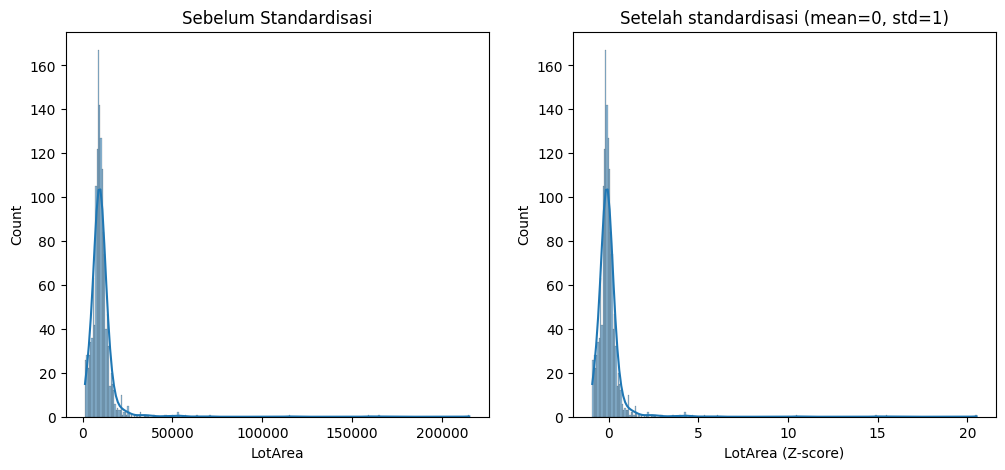

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['LotArea'], kde=True, ax=axes[0])
axes[0].set_title("Sebelum Standardisasi")
axes[0].set_xlabel('LotArea')

sns.histplot(df_standardized['LotArea'], kde=True, ax=axes[1])
axes[1].set_title("Setelah standardisasi (mean=0, std=1)")
axes[1].set_xlabel('LotArea (Z-score)')

Cek mean dan std setelah standardisasi:

In [36]:
print("Mean setelah standardisasi:", df_standardized['LotArea'].mean())
print("Std setelah standardisasi:", df_standardized['LotArea'].std())

Mean setelah standardisasi: -5.840077280220001e-17
Std setelah standardisasi: 1.0003426417780865


Sip, setelah mendapatkan hasil Setelah standardisasi, mari kita tampilkan versi yang Standardisasinya:

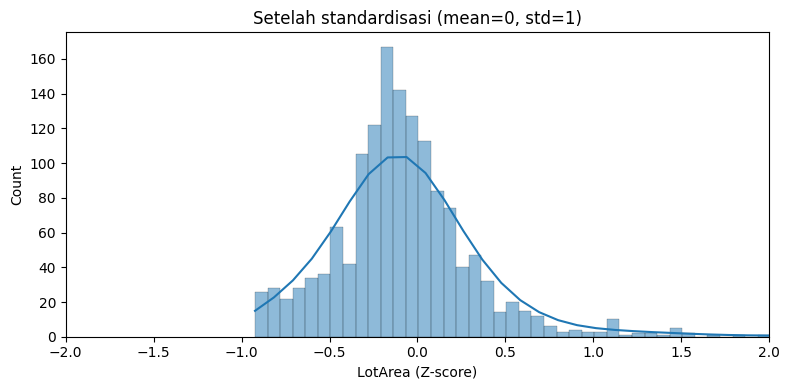

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df_standardized['LotArea'], kde=True)
plt.title("Setelah standardisasi (mean=0, std=1)")
plt.xlabel('LotArea (Z-score)')
plt.xlim(-2,2) # Batasi x-axis dari -2 sampai 2
plt.tight_layout()
plt.show()

<b>Kapan pakai standardisasi?</b> Saat membutuhkan distribusi normal dan ada outlier (cocok untuk linear regression, SVM, PCA).

<p>Jika kita tarik benang merah perbedaan dari standardisasi dengan normalisasi hanya pada rentangnya.</p>
<ul>
    <li><b>Normalisasi:</b> mengubah data ke dalam rentang [0, 1]. Ideal untuk model berbasis jarak dan data yang tidak terdistribusi normal.</li>
    <li><b>Standardisasi:</b> mengubah data sehingga rata-rata menjadi atau mendekati 0 dan standar deviasi menjadi 1. Hal ini membantu model yang memerlukan distribusi normal atau data dengan skala berbeda menjadi lebih ideal pada proses pelatihannya.</li>
</ul>
<p>Dalam praktiknya di dunia nyata, pemilihan antara normalisasi dan standardisasi sering bergantung pada algoritma yang akan digunakan dan karakteristik data. Anda perlu mempertimbangkan distribusi data dan jenis model untuk menentukan teknik preprocessing yang paling sesuai.</p>
<p>Mari kita kembali ke studi kasus yang sedang kita hadapi. Kita akan melakukan standardisasi karena membutuhkan distribusi normal dan tidak membutuhkan skala 0-1. Perhatikan kode berikut:</p>

In [55]:
from sklearn.preprocessing import StandardScaler
 
# Standardisasi fitur numerik
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

<b>Sebelumnya: </b> Install scikit-learn terlebih dahulu dengan ketik ini pada VSCode Terminal:<br>
<code>pip install scikit-learn</code>

Untuk melakukan perbandingan antara data sebelum dan sesudah dilakukan standardisasi, Anda dapat menggunakan kode berikut.


Text(0.5, 1.0, 'Histogram Sebelum Standardisasi')

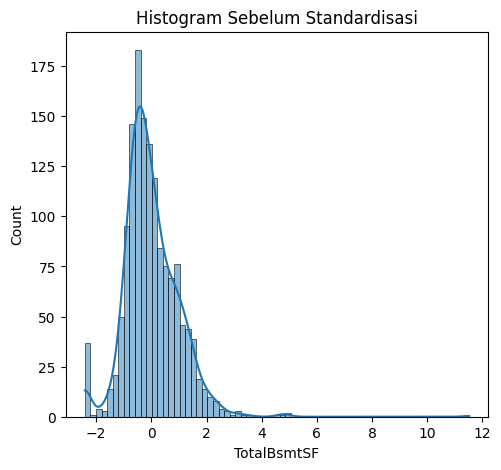

In [57]:
train = pd.read_csv(r"dataset/train.csv")

# Histogram Sebelum Standardisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# sns.histplot(train[numeric_features[3]], kde=True)
sns.histplot(df_standardized['TotalBsmtSF'], kde=True)
plt.title("Histogram Sebelum Standardisasi")

Text(0.5, 1.0, 'Histogram Setelah Standardisasi')

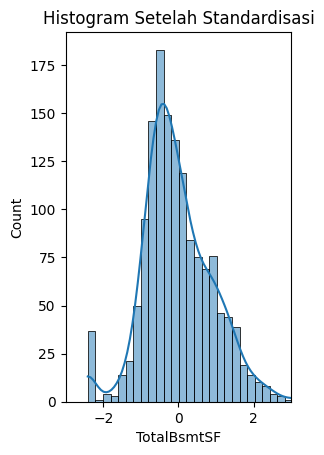

In [68]:
# Histogram Setelah Standardisasi
train = pd.read_csv(r"dataset/train.csv")

plt.subplot(1, 2, 2)
plt.xlim(-3,3)
# sns.histplot(df[numeric_features[3]], kde=True)
sns.histplot(df_standardized['TotalBsmtSF'], kde=True)
plt.title("Histogram Setelah Standardisasi")

<p>Perhatikan distribusi data pada kedua visualisasi di atas (sebelum dan sesudah standardisasi), terlihat sangat berbeda, ‘kan? Kesimpulannya, standardisasi ini akan meningkatkan kinerja model dengan menyamakan skala fitur, mempercepat konvergensi algoritma optimasi, dan mengurangi risiko overfitting.</p>
<p>Proses ini juga mempermudah interpretasi koefisien dalam model linier, memastikan konsistensi dalam perbandingan data, dan membantu deteksi outliers. Selain itu, standardisasi merupakan prasyarat bagi beberapa algoritma statistik dan machine learning, serta memungkinkan model lebih generalizable dan transferable antar dataset, menjadikannya langkah penting dalam preprocessing data.</p>
<div style="border-left: 2px solid white;">
    <div style="margin-left: 2%;">
        <b>Catatan</b>
        <p>Jika Anda menjalankan proses di atas terhadap semua fitur proses tersebut akan memakan waktu yang cukup lama, Anda dapat melewati tahapan tersebut atau disarankan menggunakan GPU agar proses yang dilakukan bisa berjalan lebih cepat.</p>
        <p>Anda juga dapat menggunakan T4 GPU yang disediakan oleh Google Colab, ya.</p>
    </div>
</div>
<p>Tenang saja, ini masih awal dari perjalanan yang lebih menegangkan. Pada materi berikutnya, Anda akan mempelajari kedua metode ini lebih detail.</p>

## Menangani Duplikasi Data
<p>Bagaimana sampai di sini apakah Anda menikmati petualangan ini? Jika iya, mari kita lanjutkan agar Anda tidak “setengah matang” menjadi seorang machine learning engineer.</p>
<p>Pada tahap ini, Anda perlu melakukan pemeriksaan kepada data yang sudah melewati tahapan-tahapan sebelumnya. Proses tersebut dapat Anda lakukan dengan menggunakan kode berikut:</p>

In [ ]:
# Mengidentifikasi baris duplikat
duplicates = df.duplicated()

print("Baris duplikat:")
print(df[duplicates])
# print(f"Duplikat berdasarkan kolom tertentu: {duplicates.sum()}")

Baris duplikat:
Empty DataFrame
Columns: [Id, MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, Heating, HeatingQC, CentralAir, Electrical, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional, Fireplaces, FireplaceQu, GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal, MoSold, YrSold, SaleType, SaleCondition, SalePrice]
Index: []

[0 rows x 8

![alt text](image/dos-a11cbef7e29044bdf9c2c584d82e42fe20241015110130.jpg)

<p>Kode yang berperan untuk melakukan tugas itu adalah duplicated(). Fungsi ini mengembalikan Series boolean yang menunjukkan apakah sebuah baris adalah duplikat atau tidak. Sayangnya seperti yang dapat Anda lihat di atas, kasus ini tidak terdapat satu pun data yang terindikasi duplikat. Oleh karena itu, kita dapat melewati tahapan ini dan melanjutkan ke tahapan berikutnya.</p>
<p>Namun, sayang rasanya jika kita melewati begitu saja tahapan ini. Mari kita bahas sedikit saja dengan catatan kita tidak akan melakukan proses ini pada studi kasus yang sedang dilakukan, ya.</p>
<p>Jika Anda menemukan data duplikat ketika menggunakan kode di atas proses penanganannya sangat sederhana, Anda hanya perlu menghapus data tersebut dengan kode berikut:</p>

In [79]:
# Menghapus baris duplikat
df = df.drop_duplicates()
 
print(f"Jumlah duplikat: {df.duplicated().sum()}")
print("DataFrame setelah menghapus duplikat:")
print(df)

Jumlah duplikat: 0
DataFrame setelah menghapus duplikat:
            Id  MSSubClass MSZoning  LotFrontage   LotArea Street Alley  \
0    -1.730865    0.073375       RL    -0.208034 -0.207142   Pave   NaN   
1    -1.728492   -0.872563       RL     0.409895 -0.091886   Pave   NaN   
2    -1.726120    0.073375       RL    -0.084449  0.073480   Pave   NaN   
3    -1.723747    0.309859       RL    -0.414011 -0.096897   Pave   NaN   
4    -1.721374    0.073375       RL     0.574676  0.375148   Pave   NaN   
...        ...         ...      ...          ...       ...    ...   ...   
1455  1.721374    0.073375       RL    -0.331620 -0.260560   Pave   NaN   
1456  1.723747   -0.872563       RL     0.615871  0.266407   Pave   NaN   
1457  1.726120    0.309859       RL    -0.166839 -0.147810   Pave   NaN   
1458  1.728492   -0.872563       RL    -0.084449 -0.080160   Pave   NaN   
1459  1.730865   -0.872563       RL     0.203918 -0.058112   Pave   NaN   

     LotShape LandContour Utilities  ...  

<p>Jika Anda sadar, kita hanya perlu menggunakan fungsi <b>drop_duplicates()</b> untuk menghapus baris yang teridentifikasi sebagai duplikat dari seluruh DataFrame.</p>

## Mengonversi Tipe Data
<p>Tahukah Anda bahwa model machine learning tidak bisa langsung menerima input kategorikal? Hal ini karena mereka bergantung pada operasi matematika yang memerlukan input numerik.</p>
<p>Sebagian besar algoritma machine learning didasarkan pada operasi matematika yang melibatkan perhitungan jarak, gradien, atau distribusi data. Misalnya, regresi linier menghitung persamaan garis menggunakan koefisien yang diterapkan pada fitur numerik. Jika data inputan berupa kategori (seperti "merah," "biru," "hijau"), tidak ada cara langsung untuk memasukkan nilai kategori tersebut ke dalam perhitungan matematika.</p>
<p>Di lain sisi, kategori seperti "merah," "biru," dan "hijau" tidak memiliki urutan atau nilai numerik inheren yang dapat dimengerti oleh model. Jika kategori diberi label numerik (misalnya, "merah" = 1, "biru" = 2, "hijau" = 3), model dapat salah menganggap bahwa ada hubungan matematis di antara kategori tersebut, seperti "biru" menjadi dua kali "merah" yang menghasilkan kesalahan persepsi sehingga mengakibatkan model tidak berjalan sesuai dengan harapan.</p>
<p>Banyak algoritma, terutama yang berbasis jarak (seperti KNN), memerlukan cara untuk mengukur jarak antar titik data. Oleh karena itu jika data bertipe kategori menyebabkan model tidak dapat mengukur jarak, misalnya, tidak ada jarak matematis yang berarti antara "merah" dan "biru."</p>
<p>Untuk mengatasi masalah ini, data kategorikal biasanya diubah menjadi bentuk numerik yang dapat dipahami oleh model yang biasa disebut encoding. Berikut beberapa contoh umum hal yang bisa kita lakukan untuk mengatasi permasalahan ini.</p>
<ul>
    <li><b>One-Hot Encoding:</b> mengubah setiap kategori menjadi kolom biner terpisah dengan nilai 0 atau 1 (bisa juga True atau False).<br><br>
    <img src="image/1-oneHotEncoding.jpeg" alt="One-Hot Encoding" width="500"/><br><br>
    </li>
    <li><b>Label Encoding:</b> memberikan label numerik untuk setiap kategori, meskipun ini hanya cocok untuk data kategorikal ordinal.<br><br>
    <img src="image/2-labelEncoding.jpeg" alt="Label Encoding" width="500"><br><br>
    </li>
    <li><b>Ordinal Encoding:</b> mengonversi kategori yang memiliki urutan menjadi nilai numerik yang mencerminkan urutan tersebut.<br><br>
    <img src="image/3-ordinalEncoding.jpeg" alt="Ordinal Encoding" width="500"><br><br>
    </li>
</ul>
<p>Sebelum kita melakukan encoding, silakan perhatikan data kategorikal yang ada pada dataset menggunakan kode berikut:</p>

In [80]:
category_features = df.select_dtypes(include=['object']).columns
df[category_features]

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1456,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1457,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Attchd,RFn,TA,TA,Y,NaN,GdPrv,Shed,WD,Normal
1458,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal


<p>Kita akan menggunakan metode one hot encoding dan label encoding karena data kategorikal yang ada pada dataset ini tidak memiliki urutan. Mari kita lakukan kedua pendekatan tersebut agar semakin terbayang perbedaannya.</p>
<h4>One Hot Encoding</h4>
<p>Penggunaan one hot encoding sangatlah mudah terutama ketika Anda telah memisahkan nama kolom untuk data kategorikal. Perhatikan kode berikut:</p>

In [81]:
df_one_hot = pd.get_dummies(df, columns=category_features)
df_one_hot

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-1.730865,0.073375,-0.208034,-0.207142,0.651479,-0.517200,1.050994,0.878668,0.510015,0.575425,...,False,False,False,True,False,False,False,False,True,False
1,-1.728492,-0.872563,0.409895,-0.091886,-0.071836,2.179628,0.156734,-0.429577,-0.572835,1.171992,...,False,False,False,True,False,False,False,False,True,False
2,-1.726120,0.073375,-0.084449,0.073480,0.651479,-0.517200,0.984752,0.830215,0.322174,0.092907,...,False,False,False,True,False,False,False,False,True,False
3,-1.723747,0.309859,-0.414011,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,-0.572835,-0.499274,...,False,False,False,True,True,False,False,False,False,False
4,-1.721374,0.073375,0.574676,0.375148,1.374795,-0.517200,0.951632,0.733308,1.360826,0.463568,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1.721374,0.073375,-0.331620,-0.260560,-0.071836,-0.517200,0.918511,0.733308,-0.572835,-0.973018,...,False,False,False,True,False,False,False,False,True,False
1456,1.723747,-0.872563,0.615871,0.266407,-0.071836,0.381743,0.222975,0.151865,0.084610,0.759659,...,False,False,False,True,False,False,False,False,True,False
1457,1.726120,0.309859,-0.166839,-0.147810,0.651479,3.078570,-1.002492,1.024029,-0.572835,-0.369871,...,False,False,False,True,False,False,False,False,True,False
1458,1.728492,-0.872563,-0.084449,-0.080160,-0.795151,0.381743,-0.704406,0.539493,-0.572835,-0.865548,...,False,False,False,True,False,False,False,False,True,False


Kode di atas akan mengubah seluruh data yang ada pada kolom category_features menjadi numerik dengan memisahkan kolom berdasarkan value yang ada. Kurang lebih hasil dari one hot encoding akan seperti berikut:

![alt text](image/dos-5eac9889717f3ea5a79ea9f5dc346f1e20241015110131.jpg)
![alt text](image/dos-8f9f49b8bb8178911132b7add046b7dd20241015110129.jpg)

<p>Perhatikan jumlah rows dan columns dari output di atas, tentunya sudah terlihat ‘kan perbedaannya? Jumlah kolom yang Anda miliki bertambah sangat banyak yang asalnya berjumlah 77 menjadi 216. Hal ini karena one hot encoding akan memecah suatu fitur menjadi fitur baru dengan struktur “namakolom_value”.</p>
<p><b>Label Encoding</b></p>
<p>Berbeda dengan one hot encoding, label encoding membutuhkan sebuah library lainnya untuk mempermudah proses pengerjaannya. Pada kasus ini, Anda akan menggunakan LabelEncoder dari sklearn sebagai senjata utama untuk melakukan encoding. Perhatikan kode berikut:</p>


In [87]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset:
df = pd.read_csv(r"dataset/train.csv")

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()
df_lencoder = pd.DataFrame(df)

category_features = df.select_dtypes(include=['object']).columns.tolist()

for col in category_features:
    df_lencoder[col] = label_encoder.fit_transform(df[col])

# Menampilkan hasil
df_lencoder


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,2,3,3,0,...,0,3,4,4,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,2,3,3,0,...,0,3,4,4,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,2,0,3,0,...,0,3,4,4,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,2,0,3,0,...,0,3,4,4,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,2,0,3,0,...,0,3,4,4,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3,62.0,7917,1,2,3,3,0,...,0,3,4,4,0,8,2007,8,4,175000
1456,1457,20,3,85.0,13175,1,2,3,3,0,...,0,3,2,4,0,2,2010,8,4,210000
1457,1458,70,3,66.0,9042,1,2,3,3,0,...,0,3,0,2,2500,5,2010,8,4,266500
1458,1459,20,3,68.0,9717,1,2,3,3,0,...,0,3,4,4,0,4,2010,8,4,142125


![alt text](image/dos-7a7c99c2a02b52769a7c220738fca67520241015110130.jpg)
![alt text](image/dos-1f3bf6b83c64a168426644592ac4f1ab20241015110129.jpg)

<p>Dengan menggunakan LabelEncoder, jumlah kolom yang ada pada data tidak mengalami perubahan sama sekali. Hal ini karena LabelEncoder hanya mengubah value dari masing-masing fitur yang ia proses.</p>
<p>Sampai di sini Diana masih memiliki sebuah pertanyaan yang sangat membebani pikirannya, “Bagaimana cara menentukan encoder yang tepat untuk setiap kasus ya?” Dengan rasa penasaran tersebut Diana mencari Bilqis dan mengajaknya untuk riset bersama.</p>
<p>Sampai di sini, mari kita bahas bersama terkait kedua pendekatan tersebut. One hot encoding dan label encoding adalah dua teknik yang sering digunakan untuk mengubah data kategorikal menjadi format numerik yang dapat digunakan dalam algoritma machine learning. Keduanya memiliki kelebihan dan kekurangan tergantung pada konteks penggunaannya. Simak kelebihan dan kekurangan dari masing-masing encoder pada materi berikut.</p>

### Kelebihan & Kekurangan
#### One-Hot Encoding
<p><b>Kelebihan</b></p>
<ol>
    <li>One-hot encoding tidak mengasumsikan adanya urutan atau hierarki di antara kategori, yang sangat cocok untuk data kategorikal nominal (misalnya, warna, jenis kelamin, dll.).</li>
    <li>Karena setiap kategori diubah menjadi kolom terpisah dengan nilai biner (0 atau 1), tidak ada risiko bahwa model akan memperlakukan satu kategori sebagai lebih besar atau lebih kecil daripada yang lain.</li>
    <li>Model yang sensitif terhadap skala numerik, seperti regresi linier, cenderung berfungsi lebih baik dengan one-hot encoding karena tidak ada hubungan numerik yang diciptakan antara kategori.</li>
</ol>
<p><b>Kekurangan</b></p>
<ol>
    <li>One-hot encoding dapat menghasilkan DataFrame dengan dimensi yang sangat tinggi jika ada banyak kategori. Hal ini bisa menyebabkan masalah "curse of dimensionality," yang membuat model lebih lambat dan memerlukan lebih banyak memori.</li>
    <li>Hasil one-hot encoding sering kali menjadi sparse matrix, di mana sebagian besar nilainya adalah 0 atau False sehingga bisa memperlambat proses pelatihan.</li>
    <li>Untuk fitur yang memiliki ribuan kategori (misalnya, kode pos), one-hot encoding bisa menjadi tidak praktis karena akan menghasilkan ribuan kolom baru.</li>
</ol>

#### Label Encoding
<p><b>Kelebihan</b></p>
<ol>
    <li>Label encoding mudah diimplementasikan dan tidak menambah dimensi dataset karena setiap kategori diubah menjadi angka tunggal.</li>
    <li>Tidak seperti one-hot encoding, label encoding tidak meningkatkan jumlah kolom dalam dataset, yang membuatnya lebih hemat memori dan lebih cepat untuk diproses.</li>
    <li>Label encoding cocok untuk data kategorikal ordinal di mana ada urutan yang jelas antara kategori (misalnya, rendah, sedang, tinggi).</li>
</ol>
<p><b>Kekurangan</b></p>
<ol>
    <li>Label encoding mengasumsikan bahwa ada urutan atau hierarki antara kategori, yang tidak selalu sesuai dengan kenyataan untuk data nominal. Ini bisa menyebabkan model membuat kesimpulan yang salah karena satu kategori mungkin dianggap lebih besar atau lebih kecil dari yang lain.</li>
    <li>Jika digunakan pada data kategorikal nominal, label encoding dapat memperkenalkan bias ke dalam model karena model dapat salah menganggap bahwa ada hubungan numerik antara kategori yang sebenarnya setara.</li>
    <li>Label encoding kurang cocok untuk fitur dengan banyak kategori karena model bisa saja memberi terlalu banyak bobot pada satu kategori yang secara numerik lebih besar daripada yang lain.</li>
</ol>

### Kesimpulan
<p>Pada akhirnya, pemilihan antara kedua metode ini tergantung pada sifat data kategorikal yang Anda miliki serta kebutuhan spesifik model yang akan Anda bangun.</p>
<p>Pada kasus ini, Diana dan Bilqis akan menggunakan LabelEncoder karena memiliki keterbatasan infrastruktur dan value yang ada bertipe ordinal sehingga sampai pada tahap ini data yang dimiliki Diana seperti berikut:</p>

![alt text](image/dos-75daf4ac4a163c9aad4387266c68817120241015110131.jpg)

<p>Sampai di sini, Diana dan Bilqis sudah mengetahui tahapan-tahapan umum untuk melakukan data cleaning dan transformation. Sebetulnya tahapan ini termasuk pada tahapan preprocessing data yang mencakup data cleaning, data transformation, dan data reduction. Namun, pada modul ini, kita hanya memahami dasarnya sebagai fondasi awal. Anda akan menemani perjalanan Diana dalam memperdalam tahapan ini pada modul feature engineering di akhir kelas, ya. Sampai jumpa di sana!</p>

<div style="border: 1px solid white">
    <div style="margin: 1%;">
        <p><b>Bacaan Tambahan</b></p>
        <p>Tahapan pada data cleaning dan transformation sangatlah beragam tergantung pada kasus yang sedang dihadapi. Sebagai bekal tambahan, dosen Diana dan Bilqis yaitu Pak Fikri memberikan bacaan tambahan yaitu buku Data Preprocessing: Feature Engineering and Extracting Feature from Text.</p>
    </div>
</div>